In [2]:
import pandas as pd
import nltk
import re
from hazm import Normalizer, word_tokenize, Stemmer, Lemmatizer
import re
import json
import random


import pickle
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter

import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from keras.models import load_model

from keras.models import Sequential
from keras.layers import Dense, Activation, Dropout
from keras.optimizers import SGD
# Create tkinter GUI
import tkinter 
from tkinter import *

# added for evaluation
from sklearn.metrics import mean_absolute_error,mean_squared_error,accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import precision_recall_curve
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split

import arabic_reshaper
from bidi.algorithm import get_display



In [3]:
intents_file = open("intents.json",encoding='utf-8').read()
intents = json.loads(intents_file)

In [4]:
# Validate intents JSON structure

for intent in intents["intents"]:

    if "tag" not in intent:
        print("Error: Missing tag")

    if "patterns" not in intent:
        print("Error: Missing patterns")

    if "responses" not in intent:
        print("Error: Missing responses")

print("Validation completed")

Validation completed


In [5]:
# Check for duplicate intent tags

tags = [intent["tag"] for intent in intents["intents"]]

duplicate_tags = set(
    tag for tag in tags
    if tags.count(tag) > 1
)

print("Duplicate tags:", duplicate_tags)

Duplicate tags: set()


In [6]:
# Check for empty patterns

for intent in intents["intents"]:

    if len(intent["patterns"]) == 0:
        print("Empty patterns:", intent["tag"])

In [7]:
# Check data types in intents

for intent in intents["intents"]:

    if not isinstance(intent["tag"], str):
        print("Invalid tag type:", intent["tag"])

    if not isinstance(intent["patterns"], list):
        print("Invalid patterns type:", intent["tag"])

    if not isinstance(intent["responses"], list):
        print("Invalid responses type:", intent["tag"])

print("Type validation completed")

Type validation completed


# Exploratory Data Analysis (EDA)


In [8]:

for intent in intents["intents"]:
    print(intent["tag"], "→", len(intent["patterns"]))

greeting → 15
accounting_definition → 18
accounting_equation → 15
asset → 9
liability → 9
equity → 9
debit_credit → 9
journal_entry → 20
journal → 15
ledger → 9
trial_balance → 9
income_statement → 9
balance_sheet → 9
revenue → 9
expense → 9
depreciation → 9
inventory → 9
accounts_receivable → 9
accounts_payable → 9
payroll → 9
tax → 9
invoice → 9
bank_reconciliation → 9
cash_flow → 8
closing_entries → 15
accounting_error → 9
accounting_standards → 19
accounting_software → 19
goodbye → 15
thanks → 15
noanswer → 9


# Create DataFrame for intent pattern counts

In [9]:
# Create DataFrame

data = []

for intent in intents["intents"]:
    data.append({
        "tag": intent["tag"],
        "num_patterns": len(intent["patterns"])
    })

data = pd.DataFrame(data)

print(data)

                      tag  num_patterns
0                greeting            15
1   accounting_definition            18
2     accounting_equation            15
3                   asset             9
4               liability             9
5                  equity             9
6            debit_credit             9
7           journal_entry            20
8                 journal            15
9                  ledger             9
10          trial_balance             9
11       income_statement             9
12          balance_sheet             9
13                revenue             9
14                expense             9
15           depreciation             9
16              inventory             9
17    accounts_receivable             9
18       accounts_payable             9
19                payroll             9
20                    tax             9
21                invoice             9
22    bank_reconciliation             9
23              cash_flow             8


In [10]:
data["num_patterns"].describe()

count    31.000000
mean     11.419355
std       3.819024
min       8.000000
25%       9.000000
50%       9.000000
75%      15.000000
max      20.000000
Name: num_patterns, dtype: float64

In [11]:
data["num_patterns"].mean()

np.float64(11.419354838709678)

In [12]:
data[data["num_patterns"] > 0]["num_patterns"].mean()

np.float64(11.419354838709678)

C:\Users\HP\AppData\Local\Temp\ipykernel_12140\3017680488.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


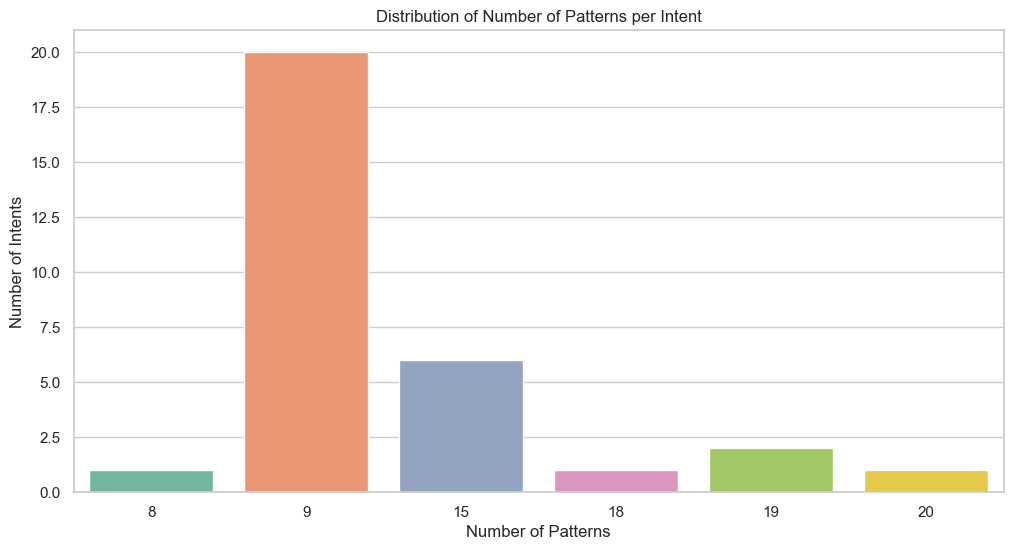

In [13]:
# Countplot of the number of patterns per intent

sns.set(style="whitegrid")

plt.figure(figsize=(12, 6)),

sns.countplot(
    data=data,
    x="num_patterns",palette='Set2'
)

plt.title("Distribution of Number of Patterns per Intent")
plt.xlabel("Number of Patterns")
plt.ylabel("Number of Intents")

plt.show()

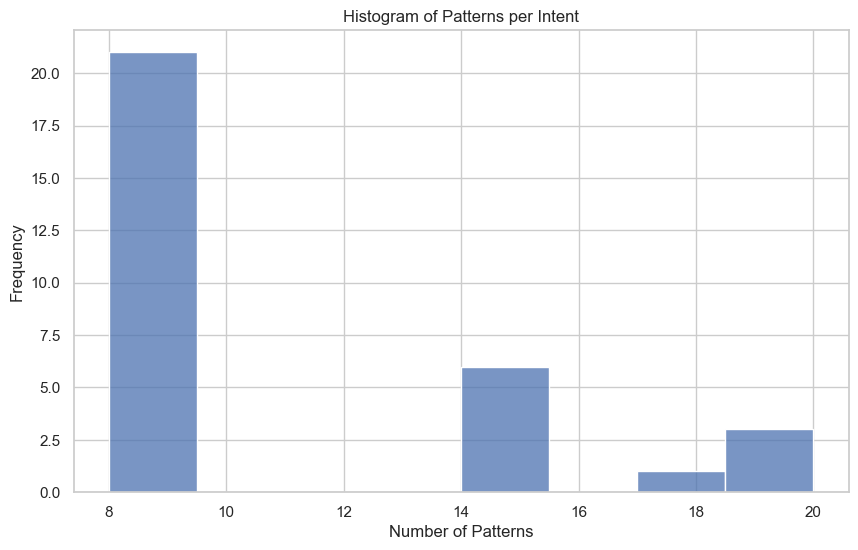

In [14]:
# Histogram of the number of patterns per intent
plt.figure(figsize=(10, 6))

sns.histplot(
    data=data,
    x="num_patterns",
    bins=8
)

plt.title("Histogram of Patterns per Intent")
plt.xlabel("Number of Patterns")
plt.ylabel("Frequency")

plt.show()

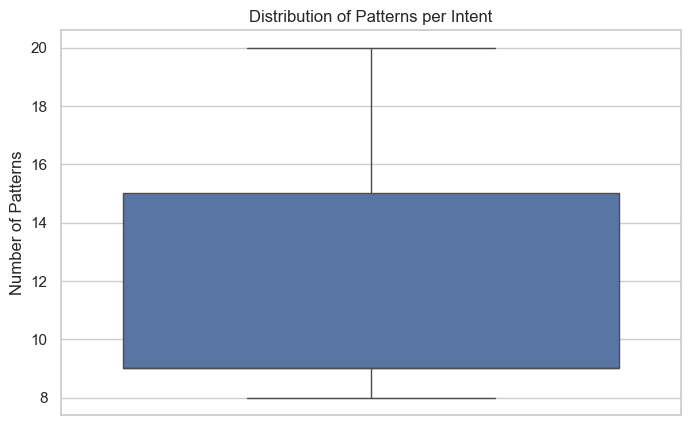

In [15]:
# Boxplot of the number of patterns per intent
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=data,
    y="num_patterns"
)

plt.title("Distribution of Patterns per Intent")
plt.ylabel("Number of Patterns")

plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_6680\448716906.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


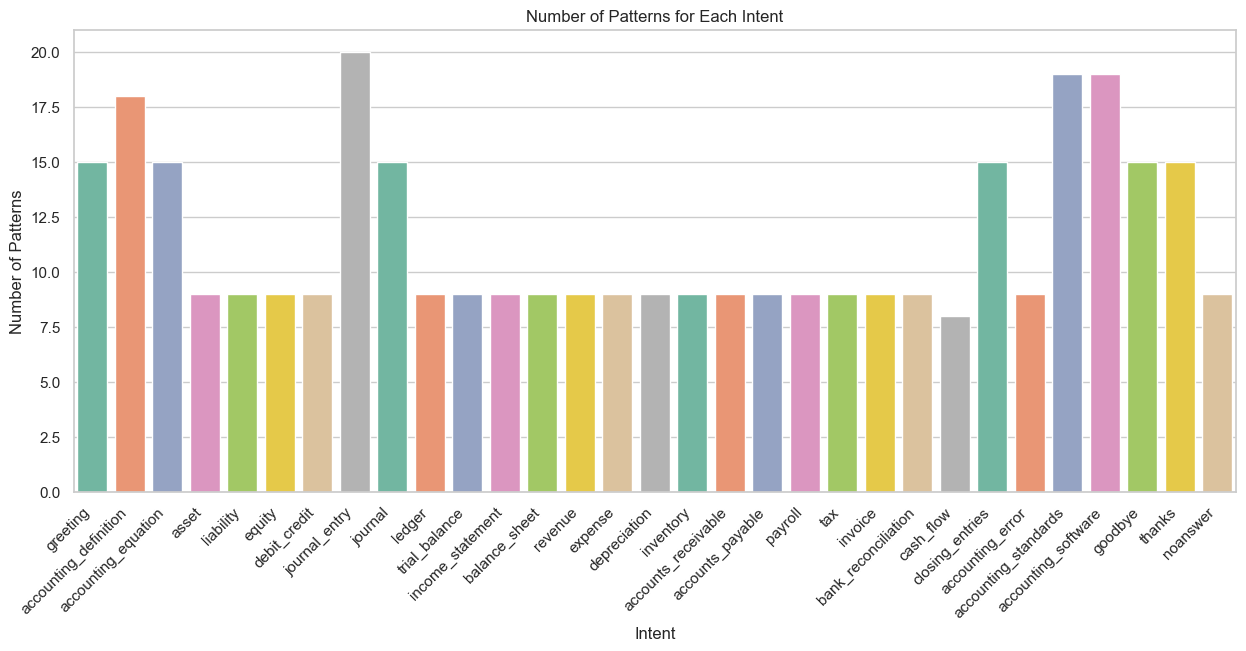

In [17]:
plt.figure(figsize=(15, 6))

sns.barplot(
    data=data,
    x="tag",
    y="num_patterns",palette='Set2'
)

plt.xticks(rotation=45, ha="right")
plt.title("Number of Patterns for Each Intent")
plt.xlabel("Intent")
plt.ylabel("Number of Patterns")

plt.show()

# Create DataFrame for pattern length analysis

In [16]:
# 
pattern_data = []

for intent in intents["intents"]:
    for pattern in intent["patterns"]:
        pattern_data.append({
            "tag": intent["tag"],
            "pattern": pattern,
            "length": len(pattern.split())
        })

pattern_df = pd.DataFrame(pattern_data)

print(pattern_df.head(25))

                      tag                        pattern  length
0                greeting                           سلام       1
1                greeting                           درود       1
2                greeting                       وقت بخیر       2
3                greeting                    سلام دستیار       2
4                greeting                   سلام حسابدار       2
5                greeting                       صبح بخیر       2
6                greeting                       عصر بخیر       2
7                greeting                        شب بخیر       2
8                greeting                       خوش آمدی       2
9                greeting                      سلام خوبی       2
10               greeting                 سلام وقتت بخیر       3
11               greeting                    درود بر شما       3
12               greeting                  سلام خدمت شما       3
13               greeting                           خوبی       1
14               greeting

In [19]:
pattern_df["length"].describe()

count    354.000000
mean       4.612994
std        1.823656
min        1.000000
25%        3.000000
50%        5.000000
75%        6.000000
max       10.000000
Name: length, dtype: float64

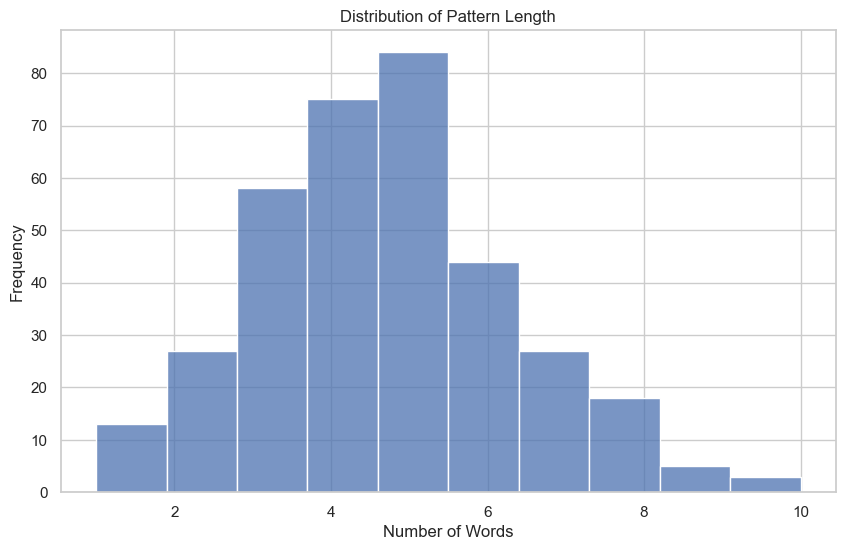

In [20]:
# Histogram of the length of patterns
plt.figure(figsize=(10, 6))

sns.histplot(
    data=pattern_df,
    x="length",
    bins=10
)

plt.title("Distribution of Pattern Length")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

# Extract all words from patterns


In [17]:

all_words = []

for pattern in pattern_df["pattern"]:
    all_words.extend(pattern.lower().split())

print(all_words[:30])

['سلام', 'درود', 'وقت', 'بخیر', 'سلام', 'دستیار', 'سلام', 'حسابدار', 'صبح', 'بخیر', 'عصر', 'بخیر', 'شب', 'بخیر', 'خوش', 'آمدی', 'سلام', 'خوبی', 'سلام', 'وقتت', 'بخیر', 'درود', 'بر', 'شما', 'سلام', 'خدمت', 'شما', 'خوبی', 'چه', 'خبر']


In [18]:

# Count word frequencies

word_counts = Counter(all_words)

print(word_counts.most_common(20))

[('چیست', 146), ('حسابداری', 100), ('چه', 58), ('ثبت', 51), ('چگونه', 50), ('و', 38), ('را', 34), ('در', 32), ('دفتر', 27), ('حساب', 26), ('از', 23), ('بده', 23), ('دارایی', 23), ('توضیح', 22), ('می', 21), ('میشود', 21), ('دارد', 20), ('است', 19), ('انجام', 18), ('بدهی', 18)]


In [19]:
# Create DataFrame for word frequency analysis

word_freq_df = pd.DataFrame(word_counts.most_common(),
    columns=["word", "frequency"])

print(word_freq_df.head(20))

        word  frequency
0       چیست        146
1   حسابداری        100
2         چه         58
3        ثبت         51
4      چگونه         50
5          و         38
6         را         34
7         در         32
8       دفتر         27
9       حساب         26
10        از         23
11       بده         23
12    دارایی         23
13     توضیح         22
14        می         21
15     میشود         21
16      دارد         20
17       است         19
18     انجام         18
19      بدهی         18


C:\Users\HP\AppData\Local\Temp\ipykernel_12140\2656935897.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


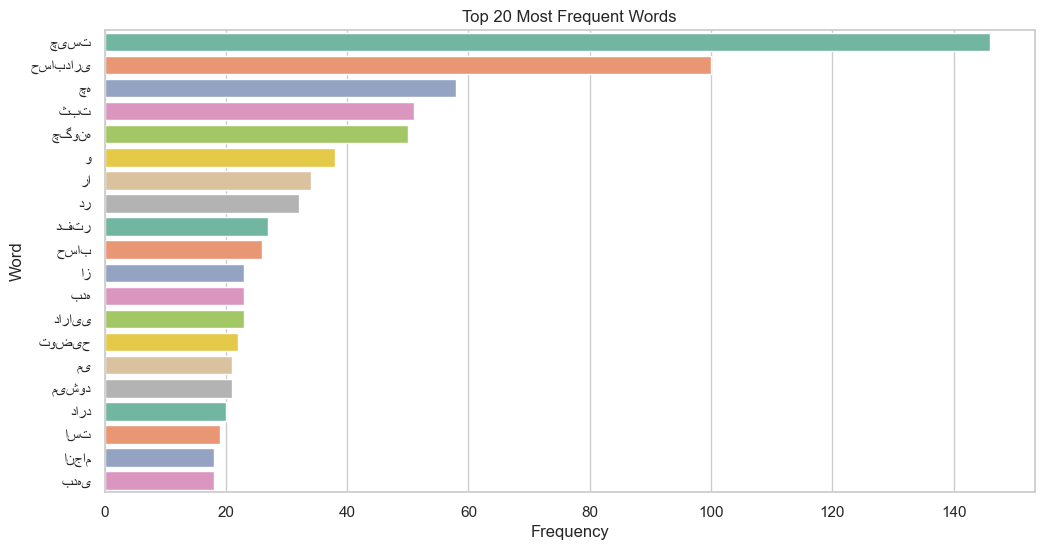

In [20]:
# Plot the 20 most frequent words

plt.figure(figsize=(12, 6))

sns.barplot(
    data=word_freq_df.head(20),palette='Set2',
    x="frequency",
    y="word"
)

plt.title("Top 20 Most Frequent Words")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.show()

In [21]:
# Check for duplicate patterns

duplicates = pattern_df[pattern_df.duplicated(subset="pattern", keep=False)]

print(duplicates)

Empty DataFrame
Columns: [tag, pattern, length]
Index: []


In [22]:
# Count duplicate patterns

print(pattern_df["pattern"].duplicated().sum())

0


In [23]:
# Show duplicated patterns and their frequencies

duplicate_counts = pattern_df["pattern"].value_counts()

print(duplicate_counts[duplicate_counts > 1])

Series([], Name: count, dtype: int64)


In [33]:
# Define common Persian stop words

stop_words = {
    "از", "به", "در", "با", "برای", "که", "و", "یا",
    "را", "این", "آن", "یک", "است", "هست", "بود",
    "باشد", "شد", "شده", "می", "من", "تو", "او",
    "ما", "شما", "آنها", "هم", "همه", "هر",
    "اگر", "اما", "ولی", "تا", "بر", "نیز",
    "چه", "چرا", "چگونه", "کدام"
}

In [34]:
# Find frequent stop words

stopword_freq = word_freq_df[
    word_freq_df["word"].isin(stop_words)
]

print(stopword_freq)

      word  frequency
2       چه         58
4    چگونه         50
5        و         38
6       را         34
7       در         32
10      از         23
14      می         21
17     است         19
22      یک         14
23    برای         14
34      با         11
66      به          6
78     چرا          5
81     شما          4
105   کدام          3
113     تا          3
120     بر          2
133     یا          2
141    اگر          2
195    شده          1
218   باشد          1


## EDA
## │
## ├── Intent count ✅
## ├── Pattern count ✅
# ├── describe() ✅
# ├── Pattern length ✅
# ├── Histogram / Barplot ✅
# ├── Duplicate patterns ✅
# ├── Word frequency ✅
# └── Stop Words 

In [35]:
normalizer = Normalizer()

normalizer.normalize("سلام خوبی اسم من محمده و  خیلی خوشهالم از این که انجامه")

'سلام خوبی اسم من محمده و خیلی خوشهالم از این\u200cکه انجامه'

In [21]:
sent_tokenize("سلام خوبی اسم من محمده و  خیلی خوشهالم از این که انجامه")

['سلام خوبی اسم من محمده و  خیلی خوشهالم از این که انجامه']

In [22]:
word_tokenize("سلام خوبی اسم من محمده و  خیلی خوشهالم از این که انجامه")

['سلام',
 'خوبی',
 'اسم',
 'من',
 'محمده',
 'و',
 'خیلی',
 'خوشهالم',
 'از',
 'این',
 'که',
 'انجامه']

In [23]:
stemmer = Stemmer()

stemmer.stem('کتاب ها')

'کتاب '

In [24]:
lemmatizer = Lemmatizer()
lemmatizer.lemmatize('کتاب ها')

'کتاب ها'

In [29]:
print("Stemmer:")
print(stemmer.stem("کتاب ها"))

print("\nLemmatizer:")
print(lemmatizer.lemmatize("کتاب ها"))

Stemmer:
کتاب 

Lemmatizer:
کتاب ها


# Data Cleaning / Preprocessing

In [36]:
# Initialize

words = []
classes = []
documents = []


# Characters to ignore

ignore_letters = [
    '!', '?', ',', '.', '،', '؟', '؛', ':', ';',
    '%', '٪',
    '-', '_',
    '(', ')', '[', ']', '{', '}',
    '"', "'",
    '«', '»',
    'ـ'
]

# Load intents

with open("intents.json", encoding="utf-8") as file:
    intents = json.load(file)


# Hazm NLP Tools

normalizer = Normalizer()
stemmer = Stemmer()
lemmatizer = Lemmatizer()

# Text preprocessing function

def preprocess_text(text):

    # 1. Normalize Persian text
    text = normalizer.normalize(text)

    # 2. Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # 3. Remove punctuation
    text = text.translate(
        str.maketrans('', '', ''.join(ignore_letters))
    )

    # 4. Tokenization
    tokens = word_tokenize(text)

    # 5. Lemmatization
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]

    return tokens


# Create words and documents

for intent in intents['intents']:

    for pattern in intent['patterns']:

        # Preprocess Persian text
        tokens = preprocess_text(pattern)

        # Add tokens to words
        words.extend(tokens)

        # Save document
        documents.append(
            (tokens, intent['tag'])
        )

        # Save class/tag
        if intent['tag'] not in classes:
            classes.append(intent['tag'])

# Remove duplicates


words = sorted(set(words))
classes = sorted(set(classes))


# Information

print("Number of words:", len(words))
print("Number of classes:", len(classes))
print("Number of documents:", len(documents))

print("\nClasses:")
print(classes)

print("\nSample words:")
print(words[:30])

Number of words: 235
Number of classes: 31
Number of documents: 354

Classes:
['accounting_definition', 'accounting_equation', 'accounting_error', 'accounting_software', 'accounting_standards', 'accounts_payable', 'accounts_receivable', 'asset', 'balance_sheet', 'bank_reconciliation', 'cash_flow', 'closing_entries', 'debit_credit', 'depreciation', 'equity', 'expense', 'goodbye', 'greeting', 'income_statement', 'inventory', 'invoice', 'journal', 'journal_entry', 'ledger', 'liability', 'noanswer', 'payroll', 'revenue', 'tax', 'thanks', 'trial_balance']

Sample words:
['#هست', 'آزمایش', 'آمد#آ', 'آیا', 'ابتدا', 'اجزا', 'اختتام', 'اختتامیه', 'اختلاف', 'ارزیابی', 'از', 'اساسی', 'است', 'استاندارد', 'استفاده', 'استهلاک', 'اشتباه', 'اشتباهات', 'اصلاح', 'اصلاحی', 'اصلی', 'اصول', 'اطلاعات', 'اطلاعاتی', 'افزار', 'الزامات', 'امید', 'انجام', 'انواع', 'اول']


In [37]:
# For saving preprocessing data
pickle.dump(words,open('persio-words.pkl','wb'))
pickle.dump(classes,open('persio-classes.pkl','wb'))


In [38]:
# Creating our training data

training = []

# Empty output for classes
output_empty = [0] * len(classes)

# Creating bag of words
for doc in documents:

    bag = []
    pattern_words = doc[0]

    for word in words:
        bag.append(1 if word in pattern_words else 0)

    # Output row for the current intent
    output_row = list(output_empty)
    output_row[classes.index(doc[1])] = 1

    # Store bag, output, pattern and tag
    training.append([
        bag,
        output_row,
        " ".join(pattern_words),
        doc[1]
    ])


# Combining and shuffling the training data
random.seed(42)
random.shuffle(training)

training = np.array(training, dtype=object)


# Splitting training data into X, Y and patterns
train_x = list(training[:, 0])
train_y = list(training[:, 1])
train_patterns = list(training[:, 2])
train_tags = list(training[:, 3])


print("Training data created")
print("Total samples:", len(train_x))

Training data created
Total samples: 354


In [41]:
# Split data into training and testing sets

x_train, X_test, y_train, y_test, pattern_train, pattern_test, tag_train, tag_test = train_test_split(
    np.array(train_x),
    np.array(train_y),
    np.array(train_patterns),
    np.array(train_tags),
    test_size=0.2,
    random_state=42,
    stratify=np.argmax(np.array(train_y), axis=1)
)

print("Training samples:", len(x_train))
print("Testing samples:", len(X_test))

Training samples: 283
Testing samples: 71


## 🧠 Model Architecture




In [42]:
# Create model
model = Sequential()
model.add(Dense(128, input_shape=(len(train_x[0]),), activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(len(train_y[0]), activation='softmax'))
model.summary()

# compile model
sgd = SGD(learning_rate=0.01, decay=1e-6, momentum=0.9, nesterov=True)
model.compile(loss='categorical_crossentropy', optimizer=sgd, metrics=['accuracy'])



C:\Users\HP\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │        30,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 31)             │         2,015 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,479 (158.12 KB)

 Trainable params: 40,479 (158.12 KB)

 Non-trainable params: 0 (0.00 B)

C:\Users\HP\AppData\Roaming\Python\Python310\site-packages\keras\src\optimizers\base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


In [43]:

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [44]:
history = model.fit(np.array(x_train), np.array(y_train),epochs=100,
    batch_size=5,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.0398 - loss: 3.4291 - val_accuracy: 0.1228 - val_loss: 3.3741
Epoch 2/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0929 - loss: 3.2910 - val_accuracy: 0.0877 - val_loss: 3.2981
Epoch 3/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1195 - loss: 3.2046 - val_accuracy: 0.1404 - val_loss: 3.1471
Epoch 4/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1637 - loss: 3.0045 - val_accuracy: 0.2281 - val_loss: 2.9644
Epoch 5/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1726 - loss: 2.8436 - val_accuracy: 0.2105 - val_loss: 2.8179
Epoch 6/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3097 - loss: 2.5737 - val_accuracy: 0.3509 - val_loss: 2.5858
Epoch 7/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3142 - loss: 2.3798 - val_accuracy: 0.3684 - val_loss: 2.3908
Epoch 8/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3628 - loss: 2.2065 - val_accuracy: 0.3860 - 

In [45]:
# Save the model
model.save("persion_chatbot_model.h5")

In [38]:
# load model
# model.load_weights('chatbot_model.h5')

# Evaluation

In [46]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [47]:
# Evaluate the model on test data

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.4215630888938904
Test Accuracy: 0.9014084339141846


In [48]:
# Predict test data

test_predictions = model.predict(X_test,verbose=0)

predicted_classes = np.argmax(test_predictions, axis=1)
true_classes = np.argmax(y_test, axis=1)

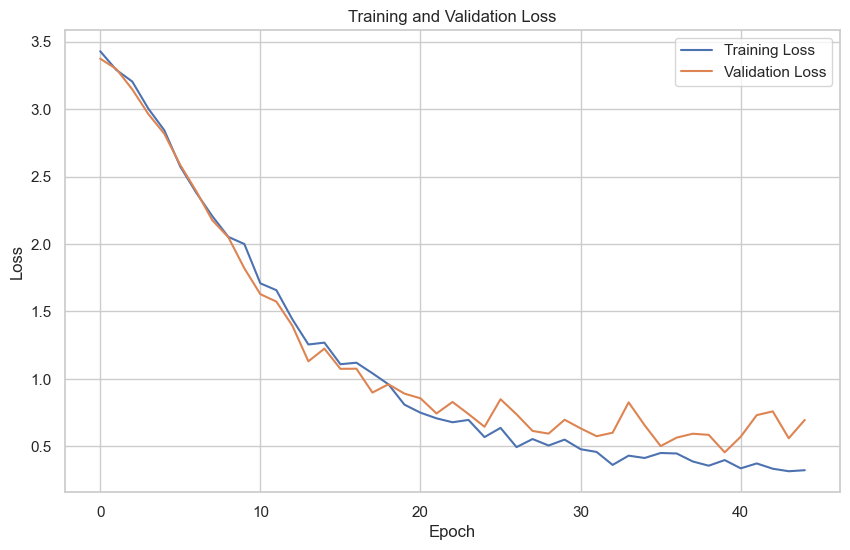

In [49]:
# Plot training and validation loss

plt.figure(figsize=(10, 6))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

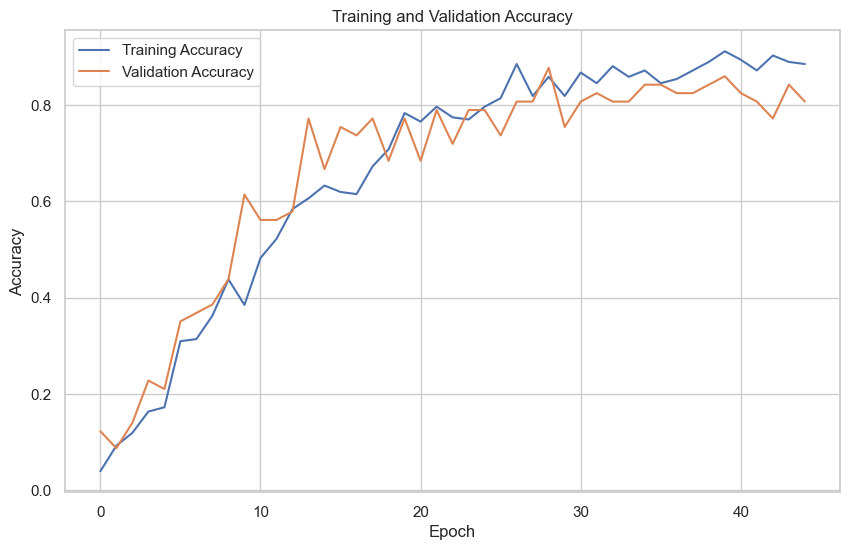

In [50]:
# Plot training and validation accuracy

plt.figure(figsize=(10, 6))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

In [51]:
# Get the best training accuracy and validation accuracy

best_accuracy = max(history.history["accuracy"])
best_val_accuracy = max(history.history["val_accuracy"])

print("Best Training Accuracy:", best_accuracy)
print("Best Validation Accuracy:", best_val_accuracy)

Best Training Accuracy: 0.9115044474601746
Best Validation Accuracy: 0.8771929740905762


In [52]:
# Get the minimum training loss and validation loss

best_loss = min(history.history["loss"])
best_val_loss = min(history.history["val_loss"])

print("Minimum Training Loss:", best_loss)
print("Minimum Validation Loss:", best_val_loss)

Minimum Training Loss: 0.31554698944091797
Minimum Validation Loss: 0.45589369535446167


In [53]:
# Get the epoch with the best validation accuracy

best_epoch = history.history["val_accuracy"].index(best_val_accuracy) + 1

print("Best Validation Epoch:", best_epoch)

Best Validation Epoch: 29


In [54]:
# Calculate training accuracy

accuracy = accuracy_score(true_classes, predicted_classes)

print("Training Accuracy:", accuracy)

Training Accuracy: 0.9014084507042254


In [55]:
# Confusion_matrix

cm = confusion_matrix(true_classes, predicted_classes)
print(cm)

[[3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0

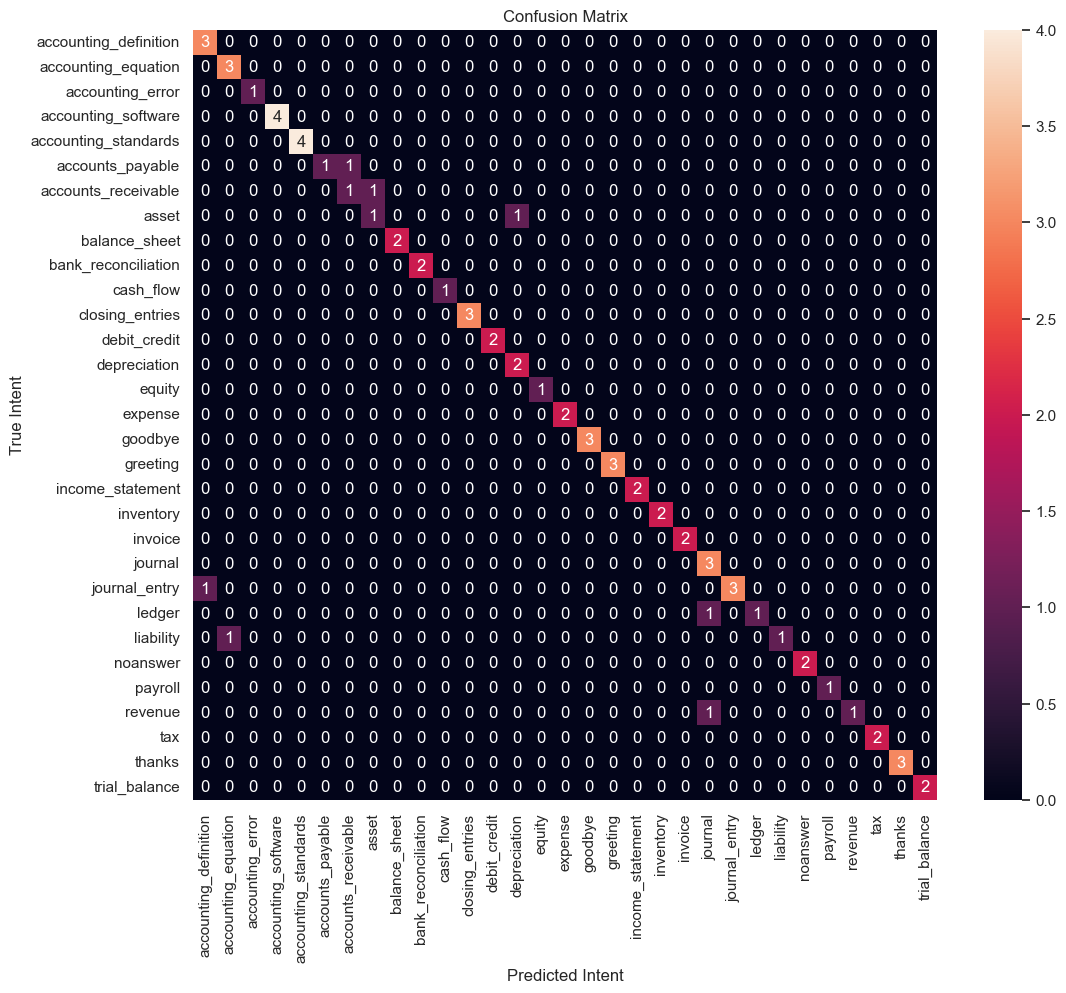

In [56]:
# Plot confusion matrix

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=classes,
    yticklabels=classes
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Intent")
plt.ylabel("True Intent")

plt.show()

In [57]:
# Find misclassified patterns
for i in range(len(true_classes)):

    if true_classes[i] != predicted_classes[i]:

        print("Pattern:", pattern_test[i])
        print("True:", classes[true_classes[i]])
        print("Predicted:", classes[predicted_classes[i]])

        print("-" * 50)

Pattern: بدهی چه تاثیر روی سرمایه داشت#دار
True: liability
Predicted: accounting_equation
--------------------------------------------------
Pattern: دفتر کل چه کاربرد داشت#دار
True: ledger
Predicted: journal
--------------------------------------------------
Pattern: منظور از سند حسابداری چیست
True: journal_entry
Predicted: accounting_definition
--------------------------------------------------
Pattern: شرکت به فروشنده بدهکار است یعنی چه
True: accounts_payable
Predicted: accounts_receivable
--------------------------------------------------
Pattern: درآمد چه تاثیر روی سرمایه داشت#دار
True: revenue
Predicted: journal
--------------------------------------------------
Pattern: دارایی در حسابداری یعنی چه
True: asset
Predicted: depreciation
--------------------------------------------------
Pattern: مطالبات شرکت چیست
True: accounts_receivable
Predicted: asset
--------------------------------------------------


In [59]:
# Generate classification report on test data

from sklearn.metrics import classification_report

report = classification_report(
    true_classes,
    predicted_classes,
    target_names=classes
)

print(report)

                       precision    recall  f1-score   support

accounting_definition       0.75      1.00      0.86         3
  accounting_equation       0.75      1.00      0.86         3
     accounting_error       1.00      1.00      1.00         1
  accounting_software       1.00      1.00      1.00         4
 accounting_standards       1.00      1.00      1.00         4
     accounts_payable       1.00      0.50      0.67         2
  accounts_receivable       0.50      0.50      0.50         2
                asset       0.50      0.50      0.50         2
        balance_sheet       1.00      1.00      1.00         2
  bank_reconciliation       1.00      1.00      1.00         2
            cash_flow       1.00      1.00      1.00         1
      closing_entries       1.00      1.00      1.00         3
         debit_credit       1.00      1.00      1.00         2
         depreciation       0.67      1.00      0.80         2
               equity       1.00      1.00      1.00  

In [60]:
print("x_train:", x_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

x_train: (283, 235)
X_test: (71, 235)
y_train: (283, 31)
y_test: (71, 31)


Hello
 ↓
Tokenize
 ↓
Lemmatize
 ↓
Bag of Words
 ↓
Model.predict()
 ↓
greeting
 ↓
انتخاب یک response

In [ ]:
# Text preprocessing

def preprocess_text(text):
    # 1. Normalize Persian text
    text = normalizer.normalize(text)

    # 2. Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # 3. Remove punctuation
    text = text.translate(
        str.maketrans('', '', ''.join(ignore_letters))
    )

    # 4. Tokenization
    tokens = word_tokenize(text)

    # 5. Lemmatization
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]

    return tokens


# Clean sentence

def clean_up_sentence(sentence):
    return preprocess_text(sentence)

# Bag of Words

def bag_of_words(sentence, words, show_details=True):

    sentence_words = clean_up_sentence(sentence)

    bag = [0] * len(words)

    for s in sentence_words:
        for i, word in enumerate(words):

            if word == s:
                bag[i] = 1

                if show_details:
                    print("found in bag:", word)

    return np.array(bag)

# Predict Intent

def predict_class(sentence):

    # Convert sentence to Bag of Words
    p = bag_of_words(
        sentence,
        words,
        show_details=True
    )

    # Model prediction
    res = model.predict(
        np.array([p]),
        verbose=0
    )[0]

    print("\nMODEL OUTPUT:")

    for i, probability in enumerate(res):
        print(
            classes[i],
            probability
        )

    # Minimum confidence threshold
    ERROR_THRESHOLD = 0.25

    results = [
        [i, r]
        for i, r in enumerate(res)
        if r > ERROR_THRESHOLD
    ]

    # Sort by probability
    results.sort(
        key=lambda x: x[1],
        reverse=True
    )

    # Create final result
    return_list = []

    for r in results:

        return_list.append({
            "intent": classes[r[0]],
            "probability": str(round(r[1], 4))
        })

    return return_list

# Get Response

def getResponse(ints, intents_json):

    if not ints:
        return "متوجه سوال شما نشدم."

    tag = ints[0]['intent']

    list_of_intents = intents_json['intents']

    for i in list_of_intents:

        if i['tag'] == tag:

            result = random.choice(i['responses'])
            break

    return result

In [ ]:
# Send Message

def send():

    msg = EntryBox.get(
        "1.0",
        "end-1c"
    ).strip()

    if msg != "":

        # Display user message

        ChatBox.config(
            state=NORMAL
        )

        ChatBox.insert(
            END,
            "You: " + msg + "\n\n"
        )

        # Predict Intent

        ints = predict_class(msg)

        print("================================")
        print("INPUT:", msg)
        print("INTENTS:", ints)

        if len(ints) > 0:

            print(
                "TOP INTENT:",
                ints[0]["intent"]
            )

            print(
                "TOP PROBABILITY:",
                ints[0]["probability"]
            )

        print("================================")

        # Get Bot Response

        res = getResponse(
            ints,
            intents
        )

        print(
            "BOT RESPONSE:",
            res
        )

        # Display Bot Response

        ChatBox.insert(
            END,
            "Bot: " + res + "\n\n"
        )

        ChatBox.config(
            state=DISABLED
        )

        ChatBox.yview(END)

        # Clear Input

        EntryBox.delete(
            "1.0",
            END
        )


# Main Window

root = Tk()

root.title("Accounting Chatbot")

root.geometry("500x650")

root.resizable(
    width=True,
    height=True
)


# Chat Window

ChatBox = Text(
    root,
    bd=0,
    bg="white",
    fg="#222222",
    height=8,
    width=50,
    font=("Tahoma", 12),
    wrap="word",
    padx=10,
    pady=10
)

ChatBox.config(
    state=DISABLED
)


# Scrollbar

scrollbar = Scrollbar(
    root,
    command=ChatBox.yview
)

ChatBox["yscrollcommand"] = scrollbar.set


# Input Frame

input_frame = Frame(
    root,
    bg="#f2f2f2"
)


# Entry Box

EntryBox = Text(
    input_frame,
    bd=1,
    relief="solid",
    bg="white",
    fg="#222222",
    insertbackground="#222222",
    width=30,
    height=4,
    font=("Tahoma", 12),
    wrap="word",
    padx=10,
    pady=8
)


# Copy
# 

def copy_text(event=None):

    try:
        EntryBox.event_generate("<<Copy>>")
    except:
        pass

    return "break"


# Paste

def paste_text(event=None):

    try:
        EntryBox.event_generate("<<Paste>>")
    except:
        pass

    return "break"


# Cut

def cut_text(event=None):

    try:
        EntryBox.event_generate("<<Cut>>")
    except:
        pass

    return "break"


# ==========================================
# Select All
# ==========================================

def select_all(event=None):

    EntryBox.tag_add(
        "sel",
        "1.0",
        "end-1c"
    )

    EntryBox.mark_set(
        "insert",
        "1.0"
    )

    EntryBox.see("insert")

    return "break"


# ==========================================
# Keyboard Shortcuts
# ==========================================

EntryBox.bind(
    "<Control-c>",
    copy_text
)

EntryBox.bind(
    "<Control-v>",
    paste_text
)

EntryBox.bind(
    "<Control-x>",
    cut_text
)

EntryBox.bind(
    "<Control-a>",
    select_all
)


# ==========================================
# Right Click Menu
# ==========================================

context_menu = Menu(
    root,
    tearoff=0
)

context_menu.add_command(
    label="Copy",
    command=copy_text
)

context_menu.add_command(
    label="Paste",
    command=paste_text
)

context_menu.add_command(
    label="Cut",
    command=cut_text
)

context_menu.add_separator()

context_menu.add_command(
    label="Select All",
    command=select_all
)


def show_context_menu(event):

    try:

        context_menu.tk_popup(
            event.x_root,
            event.y_root
        )

    finally:

        context_menu.grab_release()


EntryBox.bind(
    "<Button-3>",
    show_context_menu
)


# ==========================================
# Send Button
# ==========================================

SendButton = Button(
    input_frame,
    font=("Verdana", 12, "bold"),
    text="ارسال",
    bd=0,
    bg="#4CAF50",
    activebackground="#3c9d3b",
    fg="#000000",
    cursor="hand2",
    command=send
)


# Place Components

# ChatBox

ChatBox.place(
    x=6,
    y=6,
    height=500,
    width=460
)


# Scrollbar

scrollbar.place(
    x=466,
    y=6,
    height=500
)


# Input Frame

input_frame.place(
    x=6,
    y=520,
    width=488,
    height=120
)


# Entry Box

EntryBox.place(
    x=5,
    y=10,
    height=100,
    width=360
)


# Send Button

SendButton.place(
    x=375,
    y=10,
    height=100,
    width=100
)


# Start Application

root.mainloop()


found in bag: خوبی

MODEL OUTPUT:
accounting_definition 0.00023486154
accounting_equation 4.0452513e-05
accounting_error 6.868576e-05
accounting_software 0.00011469851
accounting_standards 4.5786972e-05
accounts_payable 0.0004896872
accounts_receivable 0.00023434147
asset 0.00025547703
balance_sheet 0.00042291044
bank_reconciliation 0.00043368698
cash_flow 0.0013435918
closing_entries 1.2989962e-05
debit_credit 8.6002095e-05
depreciation 0.001052765
equity 3.8514234e-05
expense 0.00034738675
goodbye 0.32056153
greeting 0.62620634
income_statement 0.00031514833
inventory 0.0002676391
invoice 6.050553e-05
journal 0.00027014353
journal_entry 4.6675773e-06
ledger 7.551134e-05
liability 0.00023944053
noanswer 0.004964445
payroll 1.790221e-05
revenue 0.0011141148
tax 7.986806e-05
thanks 0.040485784
trial_balance 0.00011509341
INPUT: سلا خوبي
INTENTS: [{'intent': 'greeting', 'probability': '0.6262'}, {'intent': 'goodbye', 'probability': '0.3206'}]
TOP INTENT: greeting
TOP PROBABILITY: 0.6262
